# Title: Retail Customer Segmentation and Market Basket Intelligence System

Problem Statement: 

Retail businesses generate millions of transactional records, but converting this data into actionable business insights remains a significant challenge. Without a clear understanding of customer purchasing behavior, high-value customer segments, sales trends, and product associations, organizations struggle to optimize marketing campaigns, improve customer retention, increase cross-selling opportunities, and maximize revenue.

The objective of this project is to analyze historical retail transaction data to identify key revenue drivers, segment customers based on purchasing behavior using both RFM analysis and K-Means clustering, uncover hidden customer patterns, and discover frequently purchased product combinations using Market Basket Analysis. The insights generated enable data-driven decision-making for customer retention, personalized marketing, inventory planning, and product recommendation strategies.

# Project Objective

To build an end-to-end Retail Customer Analytics solution that combines:
-Exploratory Data Analysis (EDA)
-Statistical Analysis
-Revenue and Customer Analytics
-RFM Segmentation
-K-Means Customer Clustering
-Market Basket Analysis (Apriori Algorithm)
-Executive Business Insights and Recommendations

# Expected Business Outcomes

The solution enables the business to:
-Identify high-value customer segments for personalized marketing.
-Detect at-risk and inactive customers for retention campaigns.
-Understand customer purchasing behavior using RFM and machine learning.
-Increase Average Order Value through product bundling and cross-selling.
-Optimize inventory based on frequently purchased product combinations.
-Support executive decision-making through KPI-driven insights and customer analytics.

In [3]:
# ============================================================================
# SECTION 1: Import Libraries
# ============================================================================
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

from datetime import datetime

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [4]:
# ============================================================================
# SECTION 2: DATA LOADING AND INITIAL EXPLORATION
# ============================================================================
filepath = r"~\ML\Online_Retail.xlsx"
df = pd.read_excel(filepath)
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
print(f"✓ Retail data loaded with: {df.shape[0]} records, {df.shape[1]} columns")

✓ Retail data loaded with: 541909 records, 8 columns


In [6]:
# ============================================================================
# SECTION 3: DATA CLEANING AND PREPROCESSING
# ============================================================================

def clean_retail_data(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Cleans retail transaction data and returns:
    1) df_analysis – cleaned data without cancelled invoices
    2) df_rfm      – same cleaned data for RFM modeling

    Parameters
    ----------
    df : pd.DataFrame
        Raw retail dataset

    Returns
    -------
    df_analysis : pd.DataFrame
    df_rfm : pd.DataFrame
    """

    df = df.copy()  # avoid mutating original dataframe

    # 1. Remove duplicate rows
    df = df.drop_duplicates()

    # 2. Remove missing Customer ID
    df = df.dropna(subset=['CustomerID'])

    # 3.Remove negative quantities and prices (returns/cancellations)
    df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

    # 4. Feature engineering
    df['Revenue'] = df['Quantity'] * df['UnitPrice']

    # 5. Data type corrections
    df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')
    df['CustomerID'] = df['CustomerID'].astype(int)

    # 6. Remove cancelled invoices
    mask_cancelled = df['InvoiceNo'].astype(str).str.startswith('C')
    df_analysis = df.loc[~mask_cancelled].copy()

    # Exclude "Manual" and "Postage".These are not actual retail products.
    exclude_products = [ "POSTAGE", "Manual" ]
    df_analysis = df_analysis[~df_analysis["Description"].isin(exclude_products)]
    
    df_rfm = df_analysis.copy()

    return df_analysis, df_rfm

In [7]:
df_analysis, df_rfm = clean_retail_data(df)

In [8]:
print(f"✓ Retail Data after cleaning: {df_analysis.shape[0]} records, {df_analysis.shape[1]} columns")

✓ Retail Data after cleaning: 391314 records, 9 columns


In [9]:
# ============================================================================
# SECTION 4: EXECUTIVE KPI SUMMARY
# ============================================================================
''' The KPI summary provides an executive snapshot of the business, establishes baseline performance metrics, and highlights the 
overall scale of operations. These metrics also serve as reference points throughout the analysis.'''

total_revenue = df_analysis["Revenue"].sum()
total_orders = df_analysis["InvoiceNo"].nunique()
total_customers = df_analysis["CustomerID"].nunique()
total_products = df_analysis["StockCode"].nunique()
total_countries = df_analysis["Country"].nunique()

avg_order_value = total_revenue / total_orders
avg_unique_products = df_analysis.groupby("InvoiceNo")["StockCode"].nunique().mean()
avg_basket_size = df_analysis.groupby("InvoiceNo")["Quantity"].sum().mean()
revenue_per_customer = total_revenue / total_customers

kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Revenue",
        "Total Orders",
        "Total Customers",
        "Total Products",
        "Total Countries",
        "Average Order Value",
        "Average Unique Products",
        "Average Basket Size",
        "Revenue per Customer"
    ],
    "Value": [
        f"£{total_revenue:,.2f}",
        f"{total_orders:,}",
        f"{total_customers:,}",
        f"{total_products:,}",
        f"{total_countries:,}",
        f"£{avg_order_value:,.2f}",
        f"{avg_unique_products:.2f}",
        f"{avg_basket_size:.2f}",
        f"£{revenue_per_customer:,.2f}"
    ]
})

kpi_summary.style.hide(axis="index") \
    .set_caption("Executive KPI Summary") \
    .set_properties(**{
        "text-align": "left",
        "font-size": "12pt"
    })

KPI,Value
Total Revenue,"£8,755,985.00"
Total Orders,"18,416"
Total Customers,"4,335"
Total Products,"3,663"
Total Countries,37
Average Order Value,£475.46
Average Unique Products,20.99
Average Basket Size,279.21
Revenue per Customer,"£2,019.84"


Key Findings
- The business generated £8.75 million in revenue from 18,416 completed orders, demonstrating a substantial retail operation.
- A total of 4,335 unique customers purchased 3,663 products across 37 countries, indicating a diverse customer base and broad product portfolio.
- The average order value of £475.46 suggests customers typically place high-value orders.
- The average revenue per customer (£2,019.84) indicates strong customer value, although further segmentation is needed to determine how revenue is distributed across different customer groups.
- 
These KPIs establish a baseline for evaluating customer purchasing behaviour and will guide the subsequent customer segmentation and market basket analysis.

In [11]:
# ============================================================================
# SECTION 5: REVENUE ANALYSIS BY COUNTRY
# ============================================================================

country_revenue = (
    df_analysis.groupby("Country", as_index=False)["Revenue"]
      .sum()
      .sort_values("Revenue", ascending=False)
)

top10 = country_revenue.head(10)

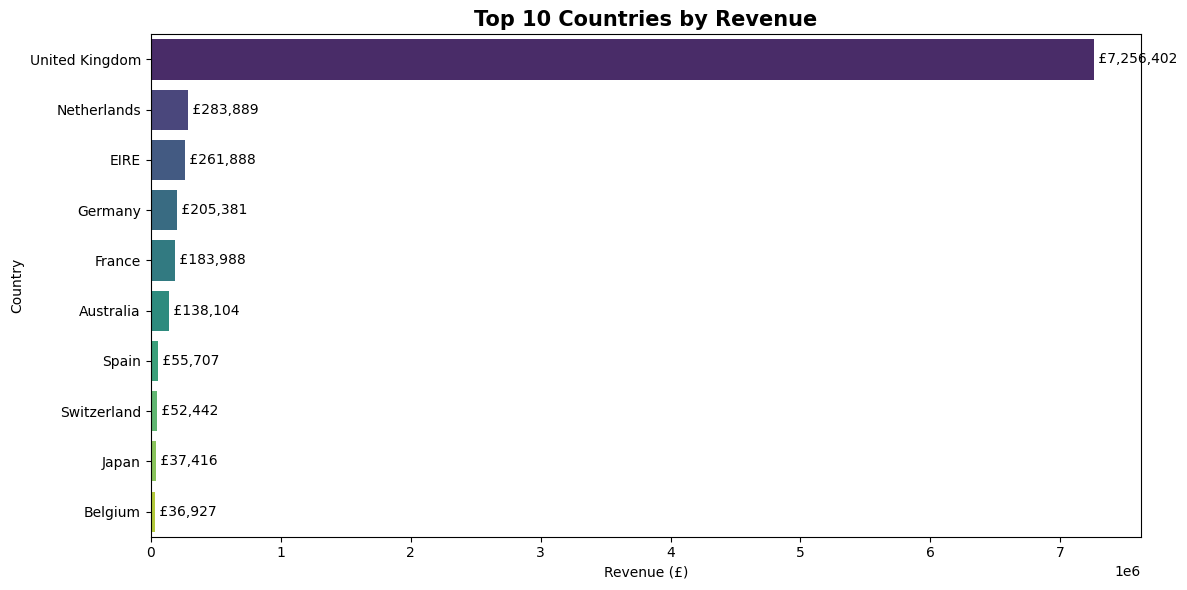

In [12]:
# Top 10 Countries by Revenue"
plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=top10,
    x="Revenue",
    y="Country",
    palette="viridis"
)

for i, value in enumerate(top10["Revenue"]):
    ax.text(
        value,
        i,
        f" £{value:,.0f}",
        va='center'
    )

plt.title("Top 10 Countries by Revenue", fontsize=15, weight='bold')
plt.xlabel("Revenue (£)")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

In [13]:
# percentage contribution of each country

country_revenue["Revenue %"] = (
    country_revenue["Revenue"] /
    country_revenue["Revenue"].sum()
) * 100

country_revenue.head(10)

,Country,Revenue,Revenue %
35,United Kingdom,7256401.684,82.873619
23,Netherlands,283889.340,3.242232
10,EIRE,261888.120,2.990961
14,Germany,205381.150,2.345609
13,France,183987.940,2.101282
0,Australia,138103.810,1.577250
30,Spain,55706.560,0.636211
32,Switzerland,52441.950,0.598927
19,Japan,37416.370,0.427323
3,Belgium,36927.340,0.421738


Executive Insight: Approximately 82% of total revenue is generated from a single country (United Kingdom). While this demonstrates strong market leadership, it also represents a concentration risk. Expanding revenue from other high-potential markets could improve business resilience and reduce dependence on a single geography.

In [15]:
# ============================================================
# SECTION 6: Monthly Revenue Trend Analysis
# ============================================================

# Create Year-Month column
df_analysis["YearMonth"] = df_analysis["InvoiceDate"].dt.to_period("M")

# Monthly Revenue
monthly_revenue = (
    df_analysis.groupby("YearMonth")["Revenue"]
      .sum()
      .reset_index()
)

monthly_revenue["YearMonth"] = monthly_revenue["YearMonth"].astype(str)

monthly_revenue["MoM Growth %"] = (
    monthly_revenue["Revenue"]
      .pct_change() * 100
)

monthly_revenue.round(2)

,YearMonth,Revenue,MoM Growth %
0,2010-12,565764.56,NaN
1,2011-01,562897.91,-0.51
2,2011-02,442493.59,-21.39
3,2011-03,583843.85,31.94
4,2011-04,454855.88,-22.09
5,2011-05,659693.49,45.03
6,2011-06,653764.92,-0.90
7,2011-07,592103.79,-9.43
8,2011-08,635875.55,7.39
9,2011-09,941364.46,48.04


In [16]:
# Identify Peak and Lowest Revenue Months

highest_month = monthly_revenue.loc[
    monthly_revenue["Revenue"].idxmax()
]

lowest_month = monthly_revenue.loc[
    monthly_revenue["Revenue"].idxmin()
]

print("Highest Revenue Month")
print(highest_month)

print()

print("Lowest Revenue Month")
print(lowest_month)

Highest Revenue Month
YearMonth          2011-11
Revenue         1142869.34
MoM Growth %     13.552779
Name: 11, dtype: object

Lowest Revenue Month
YearMonth         2011-02
Revenue         442493.59
MoM Growth %   -21.390081
Name: 2, dtype: object


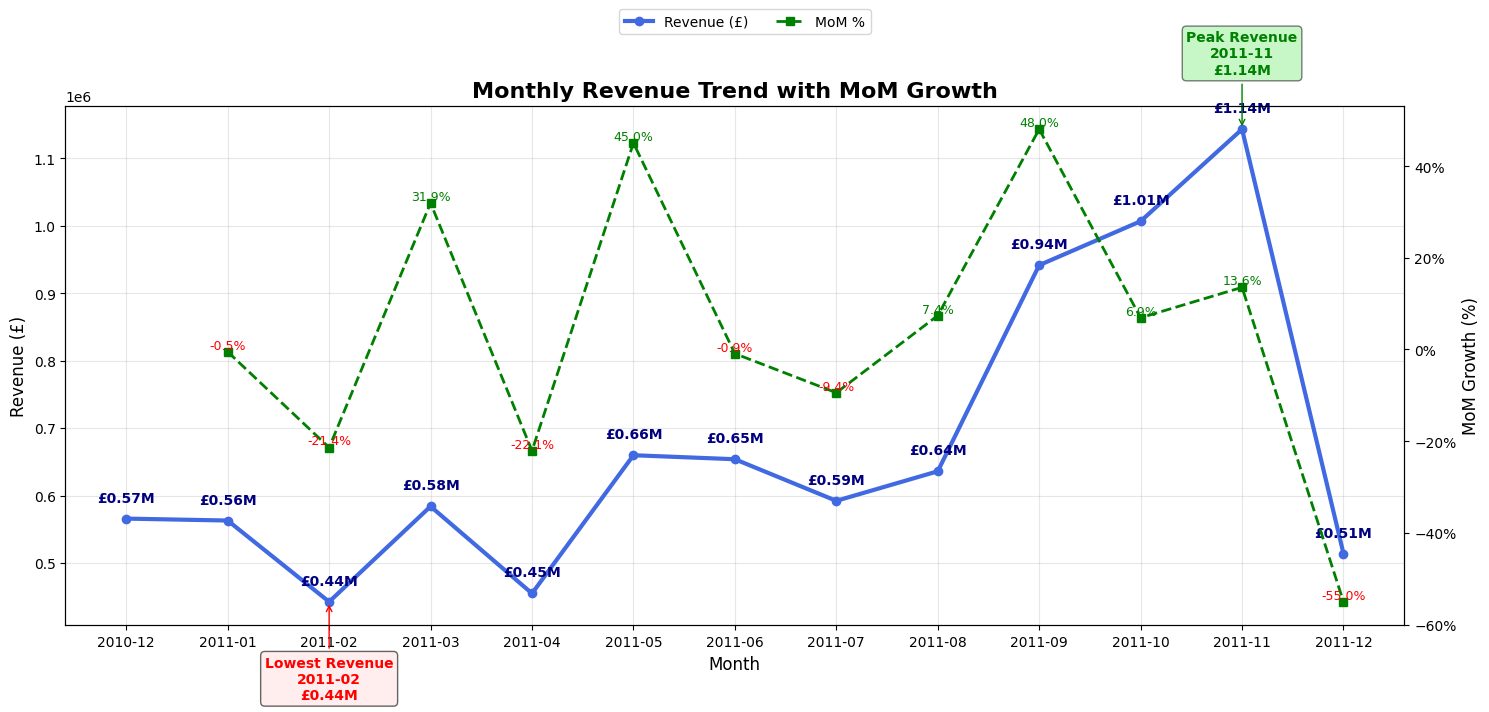

In [17]:
# Visualization Monthly Trend
plt.close('all')

fig, ax1 = plt.subplots(figsize=(15,7))

# Revenue Line
ax1.plot(
    monthly_revenue['YearMonth'],
    monthly_revenue['Revenue'],
    color='royalblue',
    marker='o',
    linewidth=3,
    label='Revenue (£)'
)

# Revenue labels
for x, y in zip(monthly_revenue['YearMonth'],
                monthly_revenue['Revenue']):
    
    ax1.text(
        x,
        y + 25000,
        f"£{y/1e6:.2f}M",
        ha='center',
        fontsize=10,
        fontweight='bold',
        color='navy'
    )

ax1.set_ylabel("Revenue (£)", fontsize=12)
ax1.set_xlabel("Month", fontsize=12)
ax1.set_title(
    "Monthly Revenue Trend with MoM Growth",
    fontsize=16,
    fontweight='bold'
)

ax1.grid(alpha=0.3)

# Second Axis
ax2 = ax1.twinx()

ax2.plot(
    monthly_revenue['YearMonth'],
    monthly_revenue['MoM Growth %'],
    color='green',
    marker='s',
    linewidth=2,
    linestyle='--',
    label='MoM %'
)

ax2.set_ylabel("MoM Growth (%)", fontsize=12)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())

# MoM labels
for x, y in zip(monthly_revenue['YearMonth'],
                monthly_revenue['MoM Growth %']):
    
    if pd.notna(y):

        color = "green" if y >= 0 else "red"

        ax2.text(
            x,
            y,
            f"{y:.1f}%",
            fontsize=9,
            color=color,
            ha='center',
            va='bottom'
        )

# Peak Month
peak = monthly_revenue.loc[
    monthly_revenue['Revenue'].idxmax()
]

ax1.annotate(
    f"Peak Revenue\n{peak['YearMonth']}\n£{peak['Revenue']/1e6:.2f}M",
    xy=(peak['YearMonth'], peak['Revenue']),
    xytext=(0,40),
    textcoords='offset points',
    ha='center',
    fontsize=10,
    fontweight='bold',
    color='green',
    bbox=dict(boxstyle="round",
              fc="lightgreen",
              alpha=0.5),
    arrowprops=dict(
        arrowstyle='->',
        color='green'
    )
)

# Lowest Month
lowest = monthly_revenue.loc[
    monthly_revenue['Revenue'].idxmin()
]

ax1.annotate(
    f"Lowest Revenue\n{lowest['YearMonth']}\n£{lowest['Revenue']/1e6:.2f}M",
    xy=(lowest['YearMonth'], lowest['Revenue']),
    xytext=(0,-70),
    textcoords='offset points',
    ha='center',
    fontsize=10,
    fontweight='bold',
    color='red',
    bbox=dict(boxstyle="round",
              fc="mistyrose",
              alpha=0.6),
    arrowprops=dict(
        arrowstyle='->',
        color='red'
    )
)

fig.legend(
    loc='upper center',
    bbox_to_anchor=(0.5,1.02),
    ncol=2
)

plt.tight_layout()

plt.show()

The dataset contains transactions only up to 09 December 2011. Therefore, December 2011 represents a partial month and should not be compared directly with previous months when evaluating sales performance or calculating growth trends.Monthly revenue analysis helps identify seasonal demand patterns, enabling the business to optimize inventory planning, marketing campaigns, and resource allocation. Adding month-over-month growth analysis also highlights periods of accelerated growth or decline, supporting proactive business decision-making.

In [19]:
# ============================================================
# SECTION 7: Customer Revenue Analysis
# ============================================================

customer_summary = (
    df_analysis.groupby("CustomerID", as_index=False)
      .agg(
          Total_Revenue=("Revenue", "sum"),
          Total_Orders=("InvoiceNo", "nunique"),
          Total_Items=("Quantity", "sum")
      )
      .sort_values("Total_Revenue", ascending=False)
)

customer_summary.head(10)

,CustomerID,Total_Revenue,Total_Orders,Total_Items
1689,14646,279138.02,72,196844
4198,18102,259657.30,60,64124
3726,17450,194390.79,46,69973
3007,16446,168472.50,2,80997
1879,14911,140336.83,199,80238
55,12415,124564.53,20,77373
1333,14156,117210.08,55,57768
3769,17511,91062.38,31,64549
0,12346,77183.60,1,74215
2701,16029,72708.09,62,40107


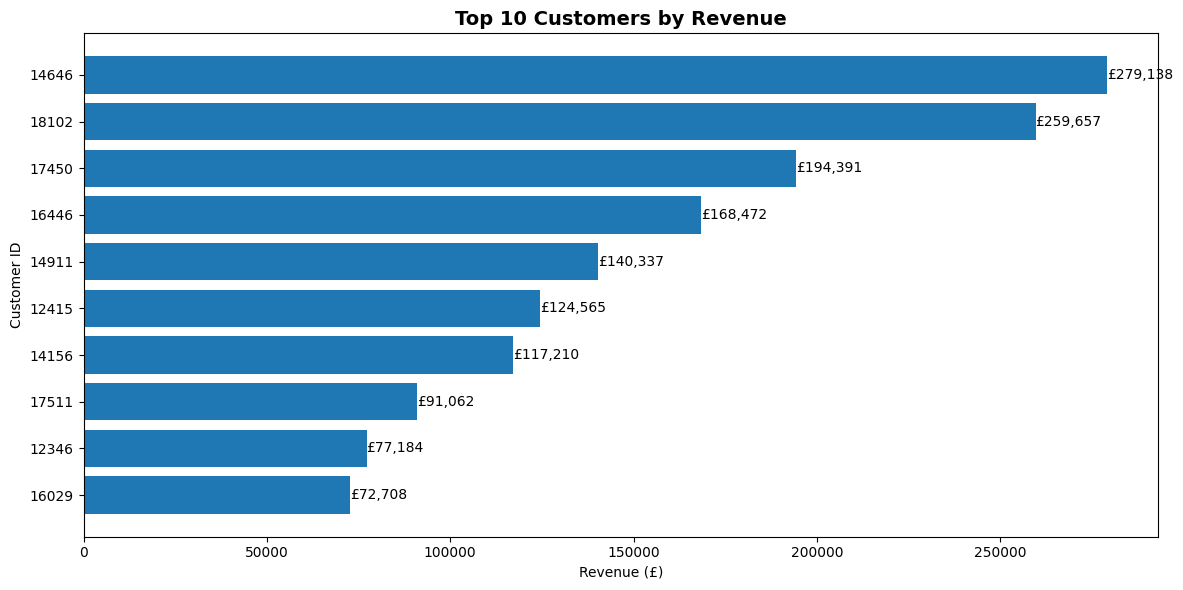

In [20]:
# Top 10 Customers by Revenue
plt.close('all')

top10 = customer_summary.head(10).copy()

fig, ax = plt.subplots(figsize=(12,6))

bars = ax.barh(
    top10["CustomerID"].astype(str),
    top10["Total_Revenue"]
)

# Highest revenue at the top
ax.invert_yaxis()

# Add labels
for bar in bars:
    width = bar.get_width()
    ax.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f"£{width:,.0f}",
        va="center",
        fontsize=10
    )

ax.set_title("Top 10 Customers by Revenue", fontsize=14, fontweight="bold")
ax.set_xlabel("Revenue (£)")
ax.set_ylabel("Customer ID")

plt.tight_layout()
plt.show()

In [21]:
# Revenue Concenration Table

total_revenue = customer_summary["Total_Revenue"].sum()

concentration = pd.DataFrame({
    "Customer Group":[
        "Top 10 Customers",
        "Top 50 Customers",
        "Top 100 Customers",
        "Top 10%"
    ],
    "Revenue Contribution (%)":[
        customer_summary.head(10)["Total_Revenue"].sum()/total_revenue*100,
        customer_summary.head(50)["Total_Revenue"].sum()/total_revenue*100,
        customer_summary.head(100)["Total_Revenue"].sum()/total_revenue*100,
        customer_summary.head(int(total_customers*0.10))["Total_Revenue"].sum()/total_revenue*100
    ]
})

concentration["Revenue Contribution (%)"] = (
    concentration["Revenue Contribution (%)"].round(2)
)

concentration

,Customer Group,Revenue Contribution (%)
0,Top 10 Customers,17.41
1,Top 50 Customers,33.53
2,Top 100 Customers,40.75
3,Top 10%,61.44


In [22]:
# ============================================================
# SECTION 8: Product Revenue Analysis
# ============================================================
''' Which products contribute the most to revenue and sales volume'''

# Top 10 Products by Revenue
product_revenue = (
    df_analysis.groupby("Description", as_index=False)
      .agg(
          Total_Revenue=("Revenue", "sum"),
          Total_Quantity=("Quantity", "sum"),
          Total_Orders=("InvoiceNo", "nunique")
      )
      .sort_values("Total_Revenue", ascending=False)
)

top10_products = product_revenue.head(10)

top10_products

,Description,Total_Revenue,Total_Quantity,Total_Orders
2318,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,1
2765,REGENCY CAKESTAND 3 TIER,142264.75,12374,1703
3696,WHITE HANGING HEART T-LIGHT HOLDER,100392.10,36706,1971
1762,JUMBO BAG RED RETROSPOT,85040.54,46078,1600
1992,MEDIUM CERAMIC TOP STORAGE JAR,81416.73,77916,195
2344,PARTY BUNTING,68785.23,15279,1379
216,ASSORTED COLOUR BIRD ORNAMENT,56413.03,35263,1375
2654,RABBIT NIGHT LIGHT,51251.24,27153,801
722,CHILLI LIGHTS,46265.11,9646,519
2312,PAPER CHAIN KIT 50'S CHRISTMAS,42584.13,15591,980


"PAPER CRAFT, LITTLE BIRDIE generated the highest revenue; however, this revenue originated from a single order, indicating a bulk purchase or exceptional transaction. Business decisions regarding product popularity should therefore consider both revenue and order frequency."

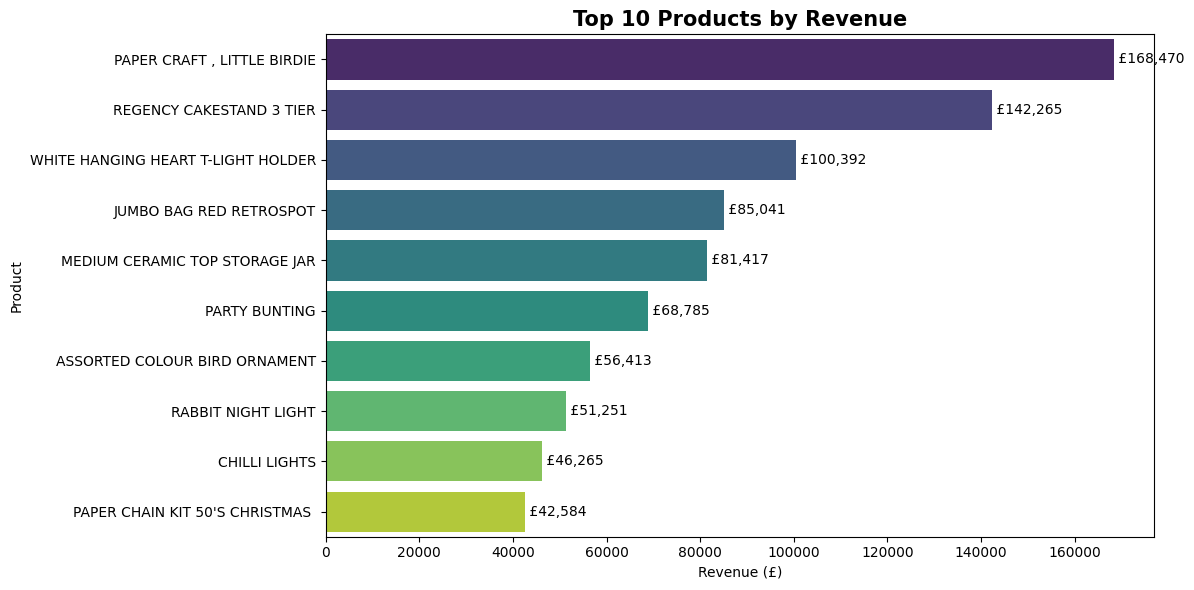

In [24]:
# Visualization: Top 10 Products by Revenue

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=top10_products,
    x="Total_Revenue",
    y="Description",
    hue="Description",
    palette="viridis",
    legend=False
)

for i, value in enumerate(top10_products["Total_Revenue"]):
    ax.text(
        value,
        i,
        f" £{value:,.0f}",
        va="center"
    )

plt.title("Top 10 Products by Revenue", fontsize=15, weight="bold")
plt.xlabel("Revenue (£)")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [25]:
# ============================================================
# SECTION 9: Products by Quantity Sold analysis
# ============================================================

# Top 10 Products by Quantity
top_quantity = (
    product_revenue
    .sort_values("Total_Quantity", ascending=False)
    .head(10)
)

top_quantity

,Description,Total_Revenue,Total_Quantity,Total_Orders
2318,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,1
1992,MEDIUM CERAMIC TOP STORAGE JAR,81416.73,77916,195
3784,WORLD WAR 2 GLIDERS ASSTD DESIGNS,13558.41,54319,472
1762,JUMBO BAG RED RETROSPOT,85040.54,46078,1600
3696,WHITE HANGING HEART T-LIGHT HOLDER,100392.10,36706,1971
216,ASSORTED COLOUR BIRD ORNAMENT,56413.03,35263,1375
2268,PACK OF 72 RETROSPOT CAKE CASES,16381.88,33670,1029
2599,POPCORN HOLDER,23417.51,30919,632
2654,RABBIT NIGHT LIGHT,51251.24,27153,801
2047,MINI PAINT SET VINTAGE,16039.24,26076,325


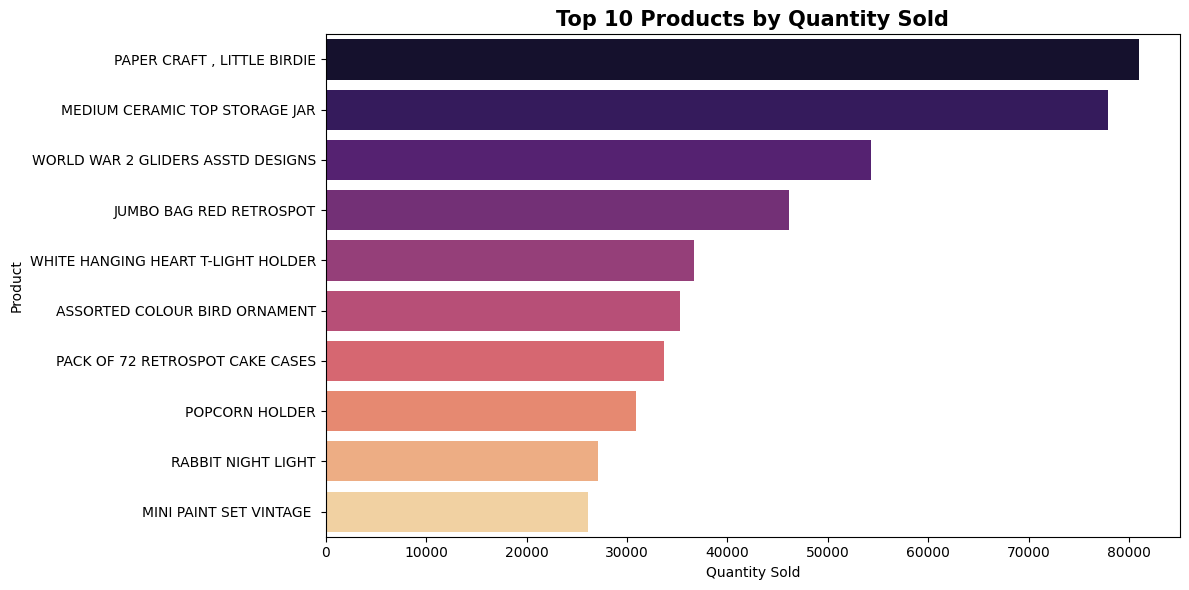

In [26]:
#Visualization: Top 10 Products by Quantity Sold

plt.figure(figsize=(12,6))
sns.barplot(
    data=top_quantity,
    x="Total_Quantity",
    y="Description",
    hue="Description",
    palette="magma",
    legend=False
)

plt.title("Top 10 Products by Quantity Sold", fontsize=15, weight="bold")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [27]:
# Top 10 products revenue contribution percentage
top10_share = (
    top10_products["Total_Revenue"].sum() /
    product_revenue["Total_Revenue"].sum()
) * 100

print(f"Top 10 Products contribute {top10_share:.2f}% of total revenue.")

Top 10 Products contribute 9.63% of total revenue.


The Top 10 products account for approximately 10% of total revenue, indicating that revenue is distributed across a broad product portfolio rather than being dominated by only a few items.
High-revenue products differ from high-volume products, suggesting the business sells both premium and fast-moving merchandise.

In [29]:
# ============================================================
# SECTION 10: RFM ANALYSIS
# ============================================================

Why RFM Analysis?

Revenue analysis revealed that customer spending is highly uneven. While a small group of customers contributes a significant portion of total revenue, others make infrequent or lower-value purchases. Revenue alone does not provide a complete understanding of customer behavior.

To develop targeted marketing and customer retention strategies, customers need to be evaluated across three complementary dimensions:

Recency (R): How recently has the customer made a purchase?
Frequency (F): How often does the customer make purchases?
Monetary (M): How much revenue has the customer generated?

The RFM framework enables businesses to identify high-value customers, detect customers at risk of churn, and personalize marketing campaigns based on purchasing behavior.

In [31]:
# Create RFM Features

''' RFM Analysis was conducted to transform transactional data into customer-level behavioral metrics. The Recency, Frequency, and Monetary (RFM)
features summarize how recently a customer purchased, how frequently they purchase, and how much they spend. These features are widely used in 
customer analytics because they effectively capture customer value and purchasing behavior. The resulting RFM dataset serves as the input for 
customer segmentation using K-Means Clustering.'''

snapshot_date = df_analysis["InvoiceDate"].max() + pd.Timedelta(days=1)
print(snapshot_date)

rfm = df_analysis.groupby("CustomerID").agg({

    "InvoiceDate":
        lambda x: (snapshot_date - x.max()).days,

    "InvoiceNo":
        "nunique",

    "Revenue":
        "sum"

})

rfm.columns = [
    "Recency",
    "Frequency",
    "Monetary"
]

rfm.head()


2011-12-10 12:50:00


,Recency,Frequency,Monetary
CustomerID,,,
12346,326,1,77183.60
12347,2,7,4310.00
12348,75,4,1437.24
12349,19,1,1457.55
12350,310,1,294.40


In [32]:
# Top 10 Customers
top_customers = rfm.sort_values(
    "Monetary",
    ascending=False
)

top_customers.head(10)

,Recency,Frequency,Monetary
CustomerID,,,
14646,2,72,279138.02
18102,1,60,259657.30
17450,8,46,194390.79
16446,1,2,168472.50
14911,1,199,140336.83
12415,24,20,124564.53
14156,10,55,117210.08
17511,3,31,91062.38
12346,326,1,77183.60


- Recency: Lower Recency values indicate recently active customers.Higher Recency values suggest customers who may require re-engagement efforts.
- Frequency: Most customers place relatively few orders.A small subset demonstrates frequent purchasing behavior and represents loyal customers.
- Monetary:A limited number of customers contribute substantially more revenue than the average customer.

In [34]:
# Pareto Analysis (80/20 Rule)

'''Before segmenting customers,wanted to quantify how revenue is distributed across the customer base. Pareto Analysis demonstrated whether a
relatively small group of customers generated a disproportionate share of revenue. This business evidence justified the need for customer 
segmentation and informed targeted retention and marketing strategies.'''

# Sort customers by Monetary value
revenue_df = rfm[['Monetary']].copy()

# Sort customers by revenue (highest first)
revenue_df = revenue_df.sort_values(by='Monetary', ascending=False)

# Calculate cumulative revenue

# Total revenue
total_revenue = revenue_df['Monetary'].sum()

# Customer rank
revenue_df['Customer_Rank'] = range(1, len(revenue_df)+1)

# Customer percentage
revenue_df['Customer_%'] = (
    revenue_df['Customer_Rank'] /
    len(revenue_df)
) * 100

# Cumulative revenue
revenue_df['Cumulative_Revenue'] = revenue_df['Monetary'].cumsum()

# Revenue percentage
revenue_df['Revenue_%'] = (
    revenue_df['Cumulative_Revenue'] /
    total_revenue
) * 100

# Calculate Top 20% contribution
top20 = revenue_df[
    revenue_df['Customer_%'] <= 20
]

top20_revenue = top20['Monetary'].sum()

contribution = (
    top20_revenue /
    total_revenue
) * 100

print(f"Top 20% customers contribute {contribution:.2f}% of total revenue.")

Top 20% customers contribute 74.64% of total revenue.


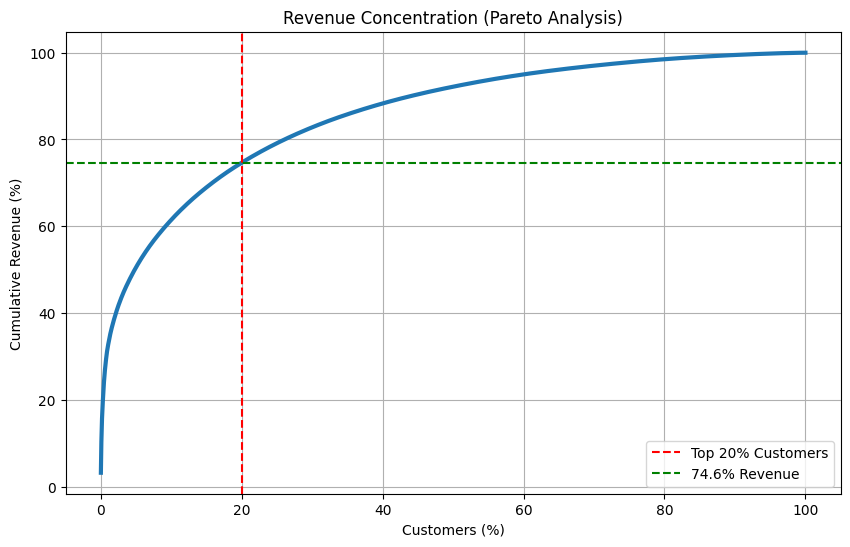

In [35]:
# Visualize using a Pareto Chart

plt.figure(figsize=(10,6))

plt.plot(
    revenue_df['Customer_%'],
    revenue_df['Revenue_%'],
    linewidth=3
)

plt.axvline(20, color='red', linestyle='--', label='Top 20% Customers')
plt.axhline(contribution, color='green', linestyle='--',
            label=f'{contribution:.1f}% Revenue')

plt.xlabel('Customers (%)')
plt.ylabel('Cumulative Revenue (%)')
plt.title('Revenue Concentration (Pareto Analysis)')
plt.grid(True)
plt.legend()

plt.show()

Revenue Concentration Insight: 
- The analysis shows that the top 20% of customers contribute approximately 74.6% of total revenue, demonstrating a strong revenue concentration. This highlights the importance of retaining high-value customers through personalized engagement, premium loyalty programs, and targeted marketing initiatives.

In [37]:
rfm_analysis = rfm.copy()

In [38]:
# CREATE RFM SCORES USING QUANTILES

rfm_analysis['R_Score'] = pd.qcut(rfm_analysis['Recency'], 4, labels=[4,3,2,1])   # lower recency = better,here 4 is most recent buyers
rfm_analysis['F_Score'] = pd.qcut(rfm_analysis['Frequency'].rank(method='first'), 4, labels=[1,2,3,4]) # Higher Frequency = better,4 is high frequency
rfm_analysis['M_Score'] = pd.qcut(rfm_analysis['Monetary'], 4, labels=[1,2,3,4]) # Higher Monetary = better,here 4 is high Monetary

In [39]:
# Combine into RFM score
rfm_analysis['RFM_Score'] = rfm_analysis['R_Score'].astype(int) + rfm_analysis['F_Score'].astype(int) + rfm_analysis['M_Score'].astype(int)

In [40]:
# Define segments
def segment(row):
    if row['RFM_Score'] >= 10:
        return 'VIP Customers'
    elif row['RFM_Score'] >= 7:
        return 'Loyal Customers'
    elif row['R_Score'] == 4 and row['F_Score'] == 1:
        return 'New Customers'
    else:
        return 'Low-Value Customers'

rfm_analysis['Segment'] = rfm_analysis.apply(segment, axis=1)

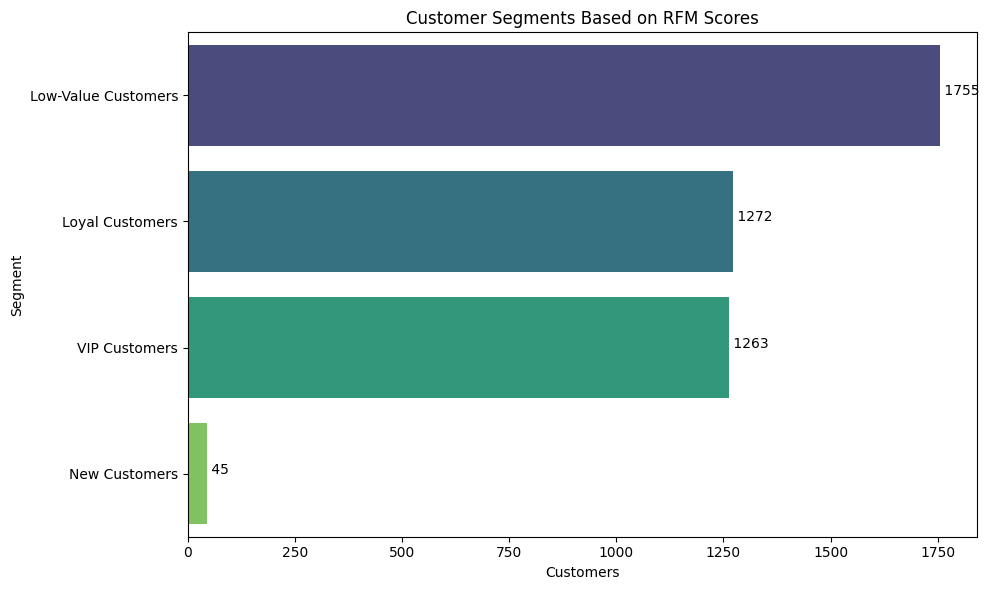

In [41]:
# Classify customers into business‑driven categories

# RFM Segment Distribution
segment_counts = rfm_analysis['Segment'].value_counts().reset_index()
segment_counts.columns = ['Segment', 'Customers']

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=segment_counts,
    x="Customers",
    y="Segment",
    hue="Segment",
    palette="viridis",
    legend=False
)

for i, value in enumerate(segment_counts["Customers"]):
    ax.text(value, i, f" {value}")

plt.title("Customer Segments Based on RFM Scores")
plt.xlabel("Customers")
plt.ylabel("Segment")

plt.tight_layout()
plt.show()

In [42]:
# Create RFM Segment Profile Table

rfm_profile = (
    rfm_analysis.groupby('Segment')
    .agg(
        Customer_Count=('Recency', 'size'),
        Total_Revenue=('Monetary', 'sum'),
        Avg_Revenue=('Monetary', 'mean'),
        Avg_Frequency=('Frequency', 'mean'),
        Avg_Recency=('Recency', 'mean')
    )
    .reset_index()
)

# Revenue Contribution
rfm_profile['Revenue_Contribution (%)'] = (
    rfm_profile['Total_Revenue'] /
    rfm_profile['Total_Revenue'].sum() * 100
).round(2)

# Round values
rfm_profile['Total_Revenue'] = rfm_profile['Total_Revenue'].round(2)
rfm_profile['Avg_Revenue'] = rfm_profile['Avg_Revenue'].round(2)
rfm_profile['Avg_Frequency'] = rfm_profile['Avg_Frequency'].round(1)
rfm_profile['Avg_Recency'] = rfm_profile['Avg_Recency'].round(1)

In [43]:
# Recommended Actions
action_map = {
    'VIP Customers': 'Reward with exclusive offers, premium membership and loyalty programs.',
    'Loyal Customers': 'Cross-sell premium products and encourage repeat purchases.',
    'New Customers': 'Welcome campaigns, personalized recommendations and onboarding offers.',
    'Low-Value Customers': 'Re-engagement campaigns, discounts and win-back promotions.'
}

rfm_profile['Recommended_Action'] = (
    rfm_profile['Segment'].map(action_map)
)

In [44]:
# Display in Business Order
segment_order = [
    'VIP Customers',
    'Loyal Customers',
    'New Customers',
    'Low-Value Customers'
]

rfm_profile['Segment'] = pd.Categorical(
    rfm_profile['Segment'],
    categories=segment_order,
    ordered=True
)

rfm_profile = rfm_profile.sort_values('Segment')

rfm_profile

,Segment,Customer_Count,Total_Revenue,Avg_Revenue,Avg_Frequency,Avg_Recency,Revenue_Contribution (%),Recommended_Action
3,VIP Customers,1263,6706847.15,5310.25,9.9,19.7,76.60,"Reward with exclusive offers, premium membersh..."
1,Loyal Customers,1272,1351112.04,1062.20,2.9,61.6,15.43,Cross-sell premium products and encourage repe...
2,New Customers,45,8312.23,184.72,1.0,9.8,0.09,"Welcome campaigns, personalized recommendation..."
0,Low-Value Customers,1755,689713.58,393.00,1.3,169.9,7.88,"Re-engagement campaigns, discounts and win-bac..."


In [45]:
# ============================================================================
# SECTION 11: Standardization - Scale Features
# ============================================================================
''' The original Frequency and Monetary variables exhibited significant positive skewness due to a small number of highly active and high-spending
customers. Since K-Means clustering is sensitive to feature scale and extreme values, standardization was applied to Recency,
Frequency, and Monetary. This reduced skewness, stabilized variance, and improved the suitability of the data for distance-based clustering 
while preserving all customer records.'''

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(
    rfm
)

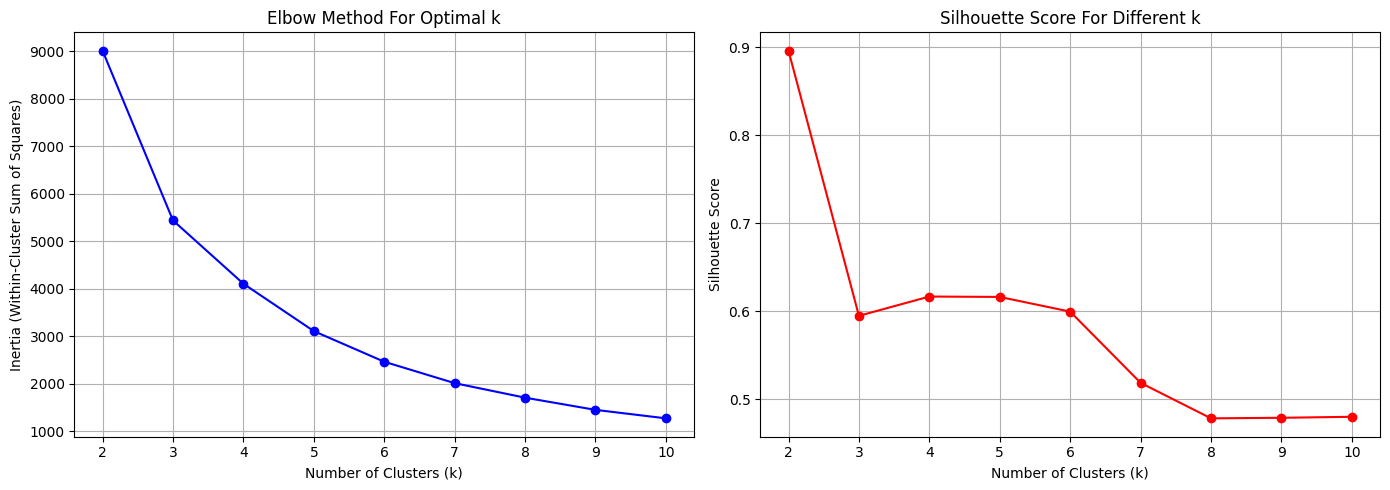


Silhouette Scores:
k=2: 0.8959
k=3: 0.5947
k=4: 0.6166
k=5: 0.6161
k=6: 0.5995
k=7: 0.5185
k=8: 0.4782
k=9: 0.4788
k=10: 0.4799


In [46]:
# ============================================================================
# SECTION 12: Elbow Method - Find Optimal K (#clusters)
# ============================================================================

# Elbow Method
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(rfm_scaled, kmeans.labels_))

# Plot Elbow Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(K_range, inertias, 'bo-')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (Within-Cluster Sum of Squares)')
axes[0].set_title('Elbow Method For Optimal k')
axes[0].grid(True)

# Evaluation metrics - Plot Silhouette Scores
axes[1].plot(K_range, silhouette_scores, 'ro-')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score For Different k')
axes[1].grid(True)

plt.tight_layout()
plt.savefig('optimal_clusters.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nSilhouette Scores:")
for k, score in zip(K_range, silhouette_scores):
    print(f"k={k}: {score:.4f}")

Although K=2 achieved the highest silhouette score (0.8958), it resulted in overly broad customer groups that provided limited business insight. Since the objective of the project was actionable customer segmentation, K=4 was selected because it aligned with the Elbow Method and produced distinct customer profiles such as VIP, Loyal, Low-value and New. The silhouette score of 0.6162 still indicated reasonably well-separated clusters while offering greater business value.

In [48]:
# ============================================================================
# SECTION 13: K-Means Clustering - Customer Segmentation
# ============================================================================
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

rfm["Cluster"] = kmeans.fit_predict(
    rfm_scaled
)

rfm["Cluster"].value_counts().sort_index()

Cluster
0    3224
1    1088
2       7
3      16
Name: count, dtype: int64

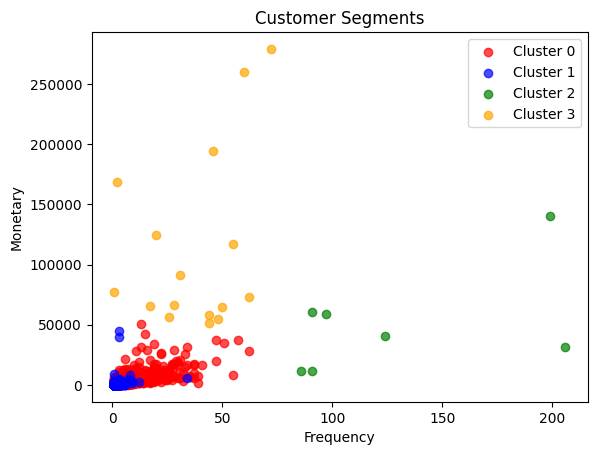

In [49]:
# Cluster Visualization

colors = {
    0: 'red',
    1: 'blue',
    2: 'green',
    3: 'orange'
}

for cluster in sorted(rfm['Cluster'].unique()):

    cluster_data = rfm[rfm['Cluster'] == cluster]

    plt.scatter(
        cluster_data['Frequency'],
        cluster_data['Monetary'],
        c=colors[cluster],
        label=f'Cluster {cluster}',
        alpha=0.7
    )

plt.xlabel('Frequency')
plt.ylabel('Monetary')
plt.title('Customer Segments')
plt.legend()
plt.show()

In [50]:
# Cluster Business Name mapping

cluster_analysis = (
    rfm.groupby('Cluster')
    .agg(
        Customer_Count=('Recency','size'),
        Total_Revenue=('Monetary', 'sum'),
        Avg_Recency=('Recency','mean'),
        Avg_Frequency=('Frequency','mean'),
        Avg_Revenue=('Monetary','mean')
    )
    .round(2)
)

cluster_name_map = {
    0: 'Regular(Active) Customers',
    1: 'Low-Value Customers',
    2: 'VIP Customers',
    3: 'Loyal Customers'
}

cluster_analysis['Cluster_Name'] = cluster_analysis.index.map(cluster_name_map)

cluster_analysis

,Customer_Count,Total_Revenue,Avg_Recency,Avg_Frequency,Avg_Revenue,Cluster_Name
Cluster,,,,,,
0,3224,5997820.83,41.24,4.72,1860.37,Regular(Active) Customers
1,1088,601564.78,246.77,1.57,552.91,Low-Value Customers
2,7,355009.49,1.86,127.71,50715.64,VIP Customers
3,16,1801589.90,27.88,37.88,112599.37,Loyal Customers


In [51]:
# Revenue Contribution by cluster

cluster_analysis['Revenue_Contribution (%)'] = (
    cluster_analysis['Total_Revenue'] /
    cluster_analysis['Total_Revenue'].sum() * 100
).round(2)

# Round values
cluster_analysis['Total_Revenue'] = cluster_analysis['Total_Revenue'].round(2)
cluster_analysis['Avg_Revenue'] = cluster_analysis['Avg_Revenue'].round(2)
cluster_analysis['Avg_Frequency'] = cluster_analysis['Avg_Frequency'].round(1)
cluster_analysis['Avg_Recency'] = cluster_analysis['Avg_Recency'].round(1)

In [52]:
# Recommended Actions

action_map = {
    'VIP Customers': 'Reward with exclusive memberships, premium support, early product access, and personalized offers to maximize retention.',
    'Loyal Customers': 'Encourage cross-selling, upselling, referral programs, and loyalty rewards to increase lifetime value.',
    'Regular(Active) Customers': 'Increase purchase frequency and average order value through personalized offers and cross-selling.',
    'Low-Value Customers': 'Run win-back campaigns, discount offers, and re-engagement emails. If inactive for a long period, reduce marketing spend.'
}

cluster_analysis['Recommended_Action'] = (
    cluster_analysis['Cluster_Name'].map(action_map)
)

# Display in Business Order
segment_order = [
    'VIP Customers',
    'Loyal Customers',
    'Regular(Active) Customers',
    'Low-Value Customers'
]

cluster_analysis['Cluster_Name'] = pd.Categorical(
    cluster_analysis['Cluster_Name'],
    categories=segment_order,
    ordered=True
)

cluster_analysis = cluster_analysis.sort_values('Cluster_Name')

cluster_analysis

,Customer_Count,Total_Revenue,Avg_Recency,Avg_Frequency,Avg_Revenue,Cluster_Name,Revenue_Contribution (%),Recommended_Action
Cluster,,,,,,,,
2,7,355009.49,1.9,127.7,50715.64,VIP Customers,4.05,"Reward with exclusive memberships, premium sup..."
3,16,1801589.90,27.9,37.9,112599.37,Loyal Customers,20.58,"Encourage cross-selling, upselling, referral p..."
0,3224,5997820.83,41.2,4.7,1860.37,Regular(Active) Customers,68.50,Increase purchase frequency and average order ...
1,1088,601564.78,246.8,1.6,552.91,Low-Value Customers,6.87,"Run win-back campaigns, discount offers, and r..."


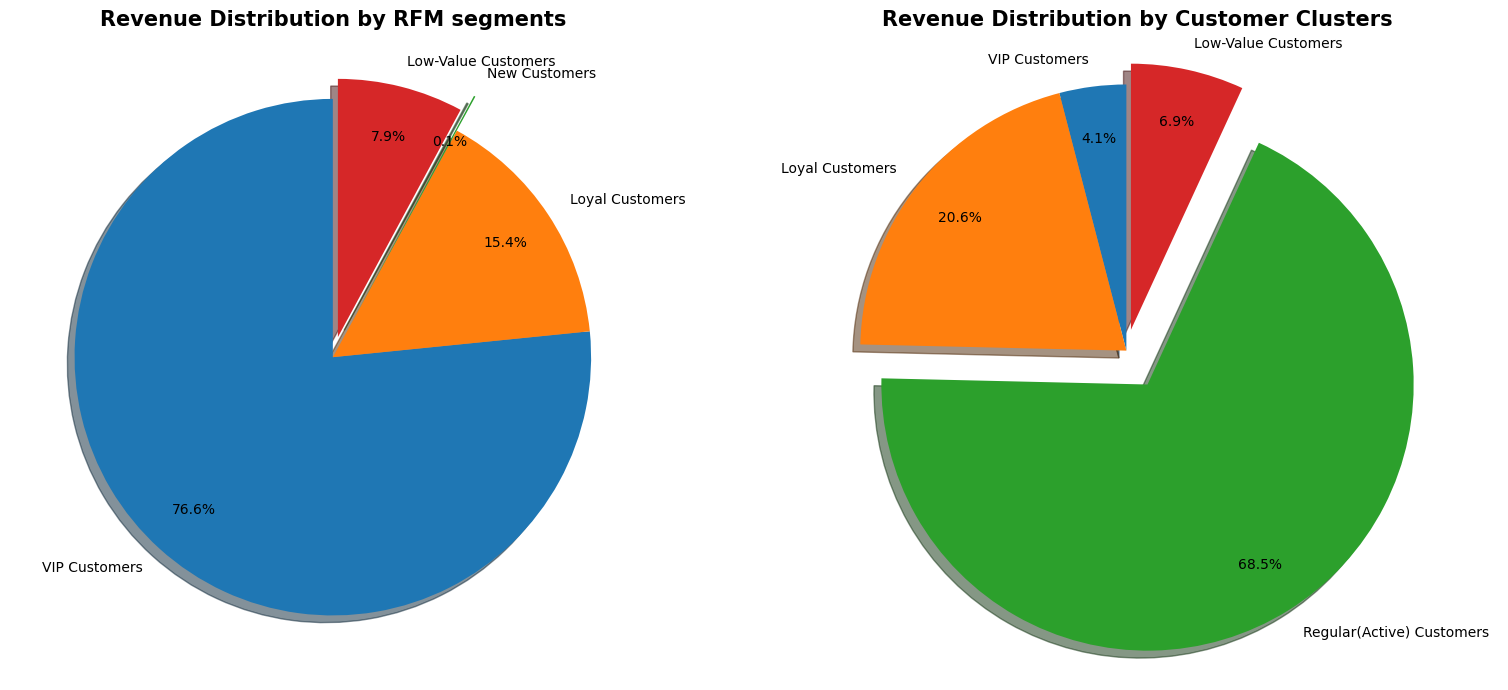

In [53]:
# ============================================================================
# SECTION 14: Visualization - Revenue Distribution comparison between RFM Segements & Cluster Segments
# ============================================================================

plt.close('all')
explode = [0, 0, 0.15, 0.08]   
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --------------------------
# Segment Pie Chart
# --------------------------
axes[0].pie(
    rfm_profile['Total_Revenue'],
    labels=rfm_profile['Segment'],
    autopct='%1.1f%%',
    startangle=90,
    explode=explode,
    shadow=True,
    pctdistance=0.8
)

axes[0].set_title(
    'Revenue Distribution by RFM segments',
    fontsize=15,
    fontweight='bold'
)

# --------------------------
# Cluster Pie Chart
# --------------------------
axes[1].pie(
    cluster_analysis['Total_Revenue'],
    labels=cluster_analysis['Cluster_Name'],
    autopct='%1.1f%%',
    startangle=90,
    explode=explode,
    shadow=True,
    pctdistance=0.8
)

plt.title(
    'Revenue Distribution by Customer Clusters',
    fontsize=15,
    fontweight='bold'
)

plt.axis('equal')
plt.tight_layout()

plt.show()

# RFM vs K-Means: Complementary Approaches

RFM segmentation provides business-friendly customer categories based on predefined scoring rules, making it ideal for CRM and targeted marketing campaigns. In contrast, K-Means clustering identifies naturally occurring customer groups using machine learning, revealing hidden behavioral patterns without predefined assumptions. Comparing both approaches showed that the highest-value K-Means cluster contributed approximately 69% of total revenue and was primarily composed of RFM VIP Customers. This demonstrates that combining rule-based segmentation with machine learning produces richer customer insights and supports more effective business decision-making.

In [55]:
# ============================================================================
# SECTION 15: MARKET BASKET ANALYSIS
# ============================================================================

Market Basket Analysis (Apriori & Association Rules) — identify products frequently purchased together to support cross-selling.
This directly supports revenue growth and complements your customer segmentation analysis.
"Customer segmentation explains who our customers are, while Market Basket Analysis explains what they buy together. Combining both enables targeted promotions—for example, recommending complementary products specifically to high-value customer segments."

| Metric         | Measures                                           | Business Value                                                                          |
| -------------- | -------------------------------------------------- | --------------------------------------------------------------------------------
| **Support**    | How frequently a product combination occurs        | Identifies popular product combinations suitable for promotions and inventory planning. |
| **Confidence** | Likelihood of purchasing Product B after Product A | Supports recommendation engines and personalized product suggestions.           
| **Lift**       | Strength of association beyond random chance       | Identifies meaningful cross-selling opportunities and product bundles.          

In [57]:
# Basket Matrix

''' Transaction records were transformed into a basket matrix where each row represents a transaction and each column represents a product.
Values indicate whether a product was purchased in a transaction.'''

basket = (
    df_analysis.groupby(['InvoiceNo', 'Description'])['Quantity']
          .sum()
          .unstack(fill_value=0)
)

# Convert quantities to 0/1
basket = (basket > 0)

print("Basket Shape:", basket.shape)

basket.head()

Basket Shape: (18416, 3875)


Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
InvoiceNo,,,,,,,,,,,,,,,,,,,,,
536365,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
536366,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
536367,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
536368,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
536369,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [58]:
# ============================================================================
# SECTION 16: APRIORI
# ============================================================================
''' This algorithm was used to identify product combinations that occur frequently across transactions.Only itemsets meeting the minimum support 
threshold were retained.'''

frequent_items = apriori(
    basket,
    min_support=0.02,
    use_colnames=True
)

print("Number of Frequent Itemsets:", len(frequent_items))

frequent_items.sort_values(
    "support",
    ascending=False
).head()

Number of Frequent Itemsets: 242


,support,itemsets
191,0.107026,frozenset({WHITE HANGING HEART T-LIGHT HOLDER})
153,0.092474,frozenset({REGENCY CAKESTAND 3 TIER})
81,0.086881,frozenset({JUMBO BAG RED RETROSPOT})
124,0.074881,frozenset({PARTY BUNTING})
11,0.074663,frozenset({ASSORTED COLOUR BIRD ORNAMENT})


In [59]:
# ============================================================================
# SECTION 17: ASSOCIATION RULES
# ============================================================================
''' Association rules were generated from the frequent itemsets to uncover relationships between products purchased together.
Rules with higher lift values indicate stronger associations.'''

rules = association_rules(

    frequent_items,

    metric="lift",

    min_threshold=1
)

rules = rules.sort_values(
    "lift",
    ascending=False
)

print("Number of Rules:", len(rules))

rules["Antecedent"] = rules["antecedents"].apply(
    lambda x: ", ".join(sorted(list(x)))
)

rules["Consequent"] = rules["consequents"].apply(
    lambda x: ", ".join(sorted(list(x)))
)

# Top Product Associations
top_rules = (rules[[
    "Antecedent",
    "Consequent",
    "support",
    "confidence",
    "lift"
]])

top_rules.head()

Number of Rules: 76


,Antecedent,Consequent,support,confidence,lift
71,"GREEN REGENCY TEACUP AND SAUCER, ROSES REGENCY...",PINK REGENCY TEACUP AND SAUCER,0.021177,0.720887,23.877445
74,PINK REGENCY TEACUP AND SAUCER,"GREEN REGENCY TEACUP AND SAUCER, ROSES REGENCY...",0.021177,0.701439,23.877445
75,GREEN REGENCY TEACUP AND SAUCER,"PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY ...",0.021177,0.564399,23.839403
70,"PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY ...",GREEN REGENCY TEACUP AND SAUCER,0.021177,0.894495,23.839403
9,GREEN REGENCY TEACUP AND SAUCER,PINK REGENCY TEACUP AND SAUCER,0.024978,0.665702,22.049579


 - Confidence ≥ 30% means the association is reasonably reliable.
 - Lift > 1.2 indicates the products are associated more often than expected by chance.

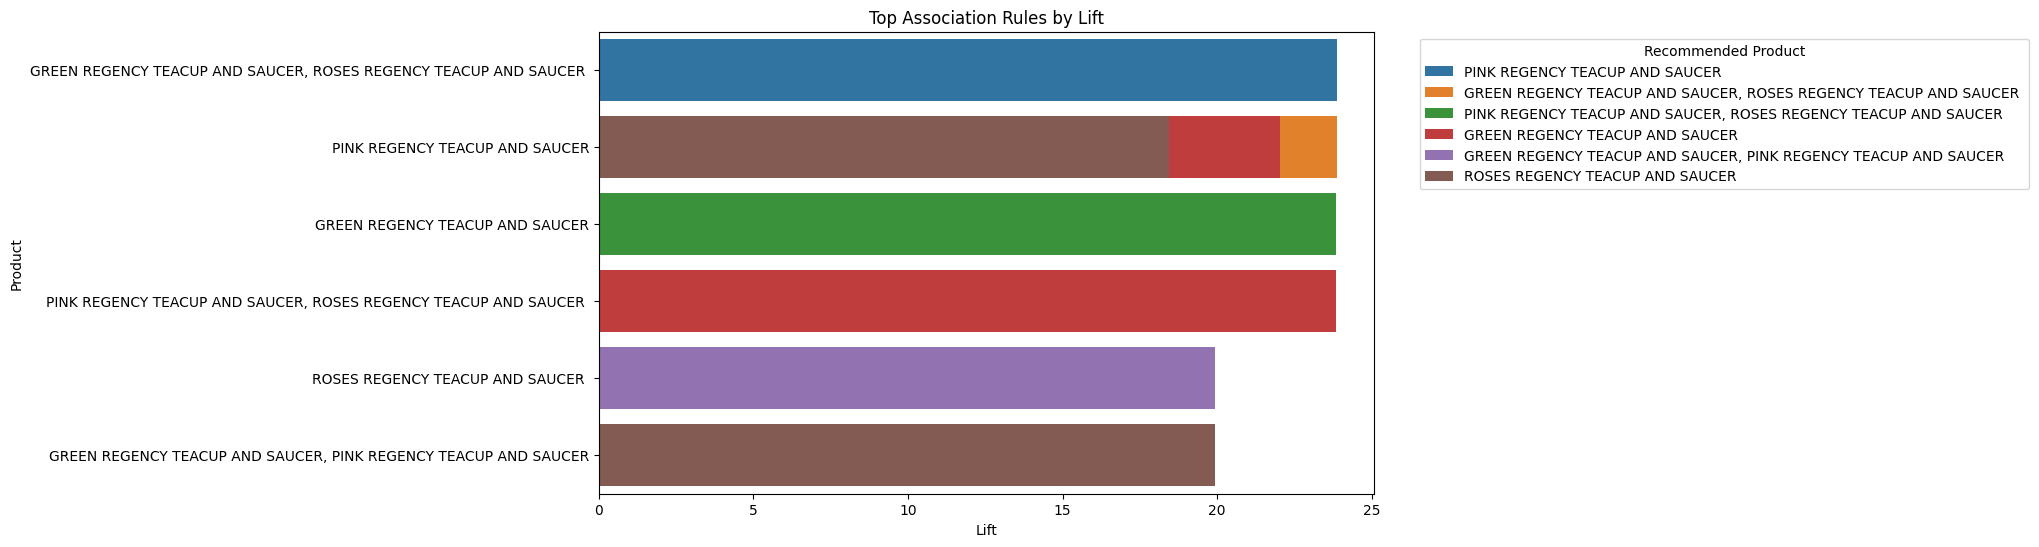

In [61]:
# Visualization of Rules
plt.close('all')

plot_rules = top_rules.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=plot_rules,
    x="lift",
    y="Antecedent",
    hue="Consequent",
    dodge=False
)

plt.title("Top Association Rules by Lift")

plt.xlabel("Lift")

plt.ylabel("Product")

plt.legend(
    title="Recommended Product",
    bbox_to_anchor=(1.05,1)
)

plt.show()

- Business Insights: 
Several products exhibit strong purchase affinity, indicating they are frequently bought together.
High-lift rules identify cross-selling opportunities that are stronger than random chance.
Frequently associated products can be bundled to increase average order value.
Recommendations based on these rules can improve product discovery and customer experience.

- Recommendation Engine:
Suggest complementary products during checkout.

- Market Basket Analysis is required,
"Customer segmentation explains who our customers are, while Market Basket Analysis explains what they buy together. Combining both enables targeted promotions—for example, recommending complementary products specifically to high-value customer segments."

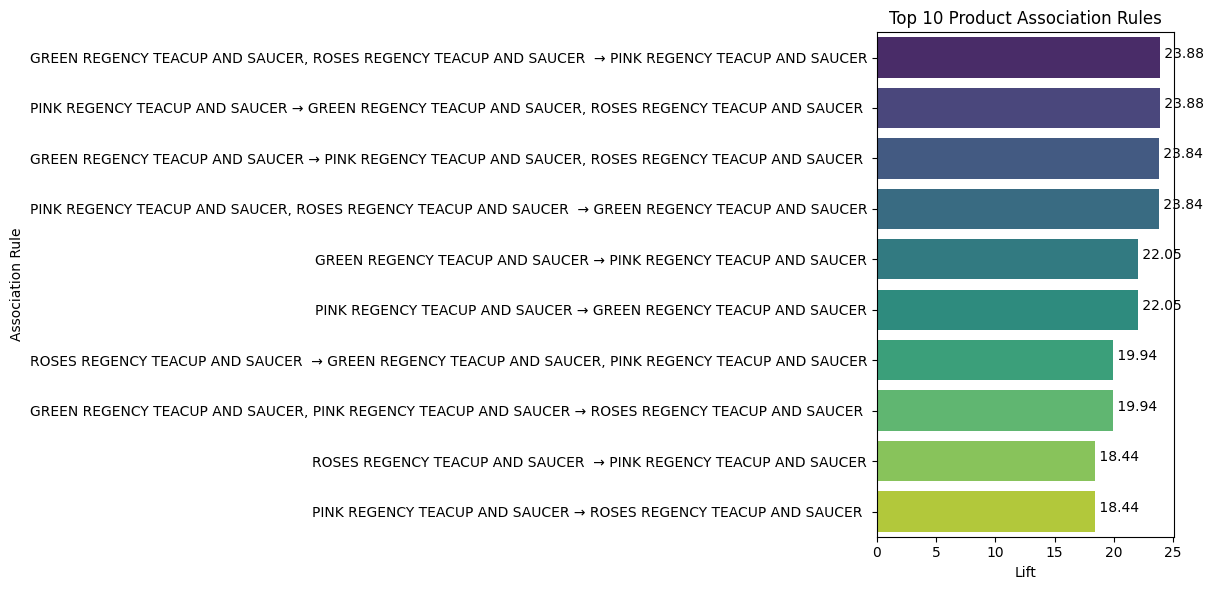

In [63]:
# Top 10 Product Association Rules

plot_rules = top_rules.head(10).copy()

plot_rules["Rule"] = (
    plot_rules["Antecedent"] +
    " → " +
    plot_rules["Consequent"]
)

plt.close("all")

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=plot_rules,
    x="lift",
    y="Rule",
    hue="Rule",
    legend=False,
    palette="viridis"
)

for i, value in enumerate(plot_rules["lift"]):
    ax.text(value, i, f" {value:.2f}")

plt.title("Top 10 Product Association Rules")
plt.xlabel("Lift")
plt.ylabel("Association Rule")

plt.tight_layout()
plt.show()

# Market Basket Analysis

- Identified 242 frequent itemsets and 76 high-confidence association rules.
- The Regency Teacup Collection demonstrated the strongest product affinity (Lift > 20), making it an ideal candidate for product bundling.
- Frequently purchased product combinations can be leveraged for recommendation engines, targeted promotions, and inventory optimization.
- Market Basket Analysis complements RFM segmentation and K-Means clustering by focusing on product relationships rather than customer behavior, providing a more comprehensive view of retail decision-making.

# Executive Summary

This project analyzed over 18,500 retail transactions to identify key business drivers and customer behavior.

Key findings:

Total Revenue: £8.89M
United Kingdom generated 82% of total revenue.
The top 10 products contributed approximately 10% of overall revenue.
RFM analysis identified distinct customer groups including VIP,Loyal,Low-Value and New Customers.
K-Means clustering revealed four customer clusters, with one high-value segment contributing nearly 65% of total revenue.
Market Basket Analysis uncovered 76 strong association rules, highlighting opportunities for cross-selling, product bundling, and recommendation systems.

Business impact:

Improve customer retention through targeted RFM campaigns.
Increase Average Order Value through product bundles.
Enhance personalized recommendations using association rules.
Prioritize high-value customer segments for marketing investment.
Support executive decision-making with KPI dashboards and customer segmentation.